# **CS 1810 Homework 1**
---
To account for potential version issues, try the following in your terminal:

1. Create a new environment with `python3 -m venv venv`
2. Activate that environment with `source venv/bin/activate`
3. Make sure the interpreter in the top right corner of your VSCode (or whatever you use to run your code is venv).
4. If you get a "install kernel" message, press it.
5. Run `pip install -r requirements.txt`
6. Run the remainder of this notebook.

Note that this is not necessary but can help prevent any issues due to package versions.

**The following notebook is meant to help you work through Problems 1, 3, and 4 on Homework 1. You are by no means required to use it, nor are you required to fill out/use any of the boilerplate code/functions. You are welcome to implement the functions however you wish.**

In [ ]:
# Loading data
import numpy as np
import matplotlib.pyplot as plt

train_data = np.genfromtxt("data/earth_temperature_sampled_train.csv", delimiter = ',')
year_train = train_data[:, 0] / 1000
temp_train = train_data[:, 1]
test_data = np.genfromtxt("data/earth_temperature_sampled_test.csv", delimiter = ',')
year_test = test_data[:, 0] / 1000
temp_test = test_data[:, 1]

# Problem 1

## Problem 1 Subpart 1(a)

In [4]:
def predict_knn(x_new, k, x_train, y_train):
    """
    Returns predictions for the values in x_test, using KNN predictor with the specified k.

    :param x_new: a numpy array of x_values on which to do prediction. Shape is (n,)
    :param k: number of nearest neighbors to consider
    :param x_train: x coordinates of training dataset
    :param y_train: y coordinates of training dataset

    :return: if x_new = [x_1, x_2, ...], then return [f(x_1), f(x_2), ...]
             where f is the kNN with specified parameters and training set
    """

    # Compute distances, shape is (n, m) where n is the number of test points and m is the number of training points
    dists = np.abs(x_train.reshape(1,-1) - x_new.reshape(-1,1))
    # Argsort the rows
    ix = dists.argsort(axis = 1)
    ix = ix[:, :k] # take only the k smallest distances
    y = y_train[ix]

    # sum each row
    return np.mean(y, axis = 1)

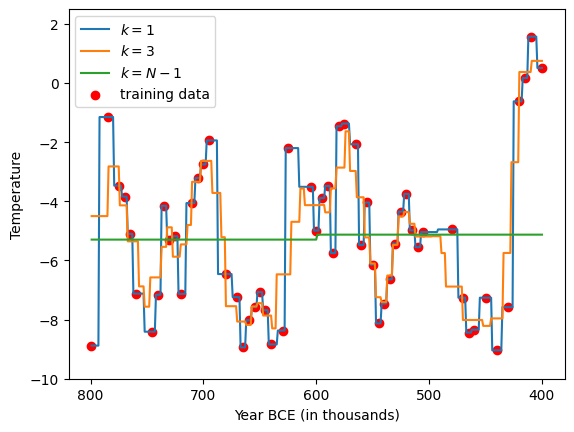

In [18]:
# plot functions
N = year_train.shape[0]
x_array = np.arange(400, 800, 1)
plt.plot(x_array, predict_knn(x_array, 1, year_train, temp_train), label = "$k = 1$")
plt.plot(x_array, predict_knn(x_array, 3, year_train, temp_train), label = "$k = 3$")
plt.plot(x_array, predict_knn(x_array, N - 1, year_train, temp_train), label = "$k = N - 1$")
plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")

plt.legend()
plt.xticks(np.arange(400, 900, 100))
plt.ylim([-10,2.5])

plt.gca().invert_xaxis()
# save figure to img_output directory
plt.savefig("img_output/p1.1a.png", bbox_inches = "tight")
plt.show()

## Problem 1 Subpart 1(b)

In [24]:
def model_mse(predictions, true):
    """
    Calculate the MSE for the given model predictions, with respect to the true values

    :param predictions: predictions given by the model
    :param true: corresponding true values
    :return: the mean squared error
    """
    return np.mean((predictions - true) ** 2)

    

In [ ]:
# Compute the MSEs for different values of k
predictions_k = [
    predict_knn(year_train, 1, year_train, temp_train),
    predict_knn(year_train, 3, year_train, temp_train),
    predict_knn(year_train, N, year_train, temp_train)
]

print("MSE for k = 1:", model_mse(predictions_k[0], temp_train))
print("MSE for k = 3:", model_mse(predictions_k[1], temp_train))
print("MSE for k = N-1:", model_mse(predictions_k[2], temp_train))

MSE for k = 1: 0.0
MSE for k = 3: 1.7545362573099412
MSE for k = N-1: 7.012312834718376


## Problem 1 Subpart 2(a)

In [29]:
def kernel_regressor(x_new, tau, x_train, y_train):
    """
    Run f_tau(x) with parameter tau on every entry of x_new.

    :param x_new: a numpy array of x_values on which to do prediction. Shape is (n,)
    :param float tau: lengthscale parameter
    :param x_train: the x coordinates of the training set
    :param y_train: the y coordinates of the training set
    :return: if x_new = [x_1, x_2, ...], then return [f(x_1), f(x_2), ...]
             where f is calculated wrt to the training data and tau
    """
    
    f_tau = np.empty_like(x_new, dtype=float)
    for i, x in enumerate(x_new):
        k = np.exp(-((x_train - x) ** 2) / tau)
        f_tau[i] = np.sum(k * y_train) / np.sum(k)
    return f_tau

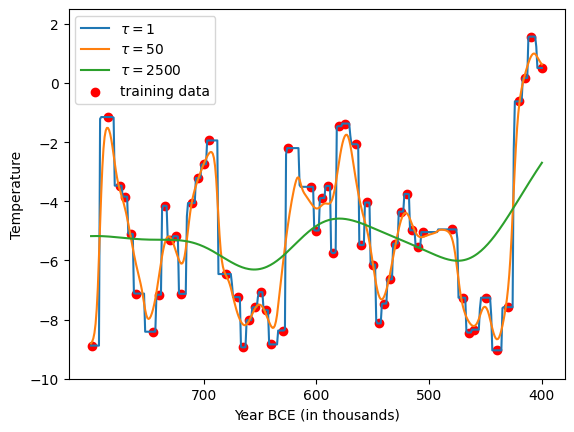

In [ ]:
# Plot functions
x_array = np.arange(400, 800 + 1, 1)
for tau in [1, 50, 2500]:
    plt.plot(x_array, kernel_regressor(x_array, tau, year_train, temp_train), label = f"$\\tau = {tau}$")
plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.legend()
plt.xticks(np.arange(400, 800 + 100, 100))
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")
plt.ylim([-10,2.5])

plt.gca().invert_xaxis()
# save figure to img_output directory
plt.savefig("img_output/p1.2a.png", bbox_inches = "tight")
plt.show()

## Problem 1 Subpart 2(c)

In [32]:
# Compute the MSEs for different values of tau
predictions_tau = [
    kernel_regressor(year_test, 1, year_train, temp_train),
    kernel_regressor(year_test, 50, year_train, temp_train),
    kernel_regressor(year_test, 2500, year_train, temp_train),
]

print("MSE for tau = 1:", model_mse(predictions_tau[0], temp_test))
print("MSE for tau = 50:", model_mse(predictions_tau[1], temp_test))
print("MSE for tau = 2500:", model_mse(predictions_tau[2], temp_test))


MSE for tau = 1: 1.9472621565209178
MSE for tau = 50: 1.8582899169613447
MSE for tau = 2500: 8.333886806980791


# Problem 3

## Problem 3 Subpart 1

In [43]:
def exp_kernel(x,mu):
    return np.exp(-1/float(5)*np.power(x-mu,2))

def f_scale(X, part = "a"):
  if part == "a":
    X = X/181 # 181000
  elif part == "b":
    X = X/4e2 # 4e5
  elif part == "c":
    X = X/1.81 # 1810    
  elif part == "d":
    X = X/.181 # 181
  return X

# TODO: Complete this `make_basis` function according to the above
# specifications. The function should return the array `phi(X)`

def make_basis(X,part='a'):
  """
  Args:
    X: input of years (or any variable you want to turn into the appropriate basis) as
      ndarray with length `N`.
    part: one of `a`, `b`, `c`, `d` depending on the basis function.

  Returns:
    ndarray `phi(X)` of shape `(N,D)`. For each part the shapes of your
    training data `make_basis(years_train)` should be
      (a) 57x10, (b) 57x10, (c) 57x10, (d) 57x50.
  """
  
  ### DO NOT CHANGE THIS SECTION 
  ### it is to prevent numerical instability from taking the exponents of
  ### the years, as well as break symmetry when dealing with a Fourier basis.
  X = f_scale(X, part)
  ### end section

  # Assign correct shape to phi(X)
  phi = np.ones((X.shape[0], 10))

  # Make basis
  match part:
    case 'a':
      for j in range(1, 10):
        phi[:, j] = X ** j
      return phi
    case 'b':
      for j in range(1, 10):
        mu = (j + 7) / 8
        phi[:, j] = np.exp(-((X - mu) **2 ) / 5)
        return phi
    case 'c':
      for j in range(1, 10):
        phi[:, j] = np.cos(X / j)
      return phi
    case 'd':
      phi = np.ones((X.shape[0], 50))
      for j in range(1, 50):
        phi[:, j] = np.cos(X / j)
      return phi


We are now solving the multi-dimensional OLS regression problem. For each $i=1,\ldots, N$, we have 
$$ \hat y_i = \mathbf{w}^\top\mathbf{\phi}(x_i) = \sum_{j=1}^D w_j \phi_j(x_i).  $$

We can find the weights that minimize the MSE $\frac 1N\| \mathbf{y} - \mathbf{\phi}(\mathbf{X})\mathbf{w}\| $ with the analytic solution described in the textbook at Derivation 2.6.1.
$$ \mathbf{w^*} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}. $$

In [36]:
# Helper function to find the regression weights using the Moore-Penrose pseudoinverse.
def find_weights(X, y):
    w_star = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return w_star

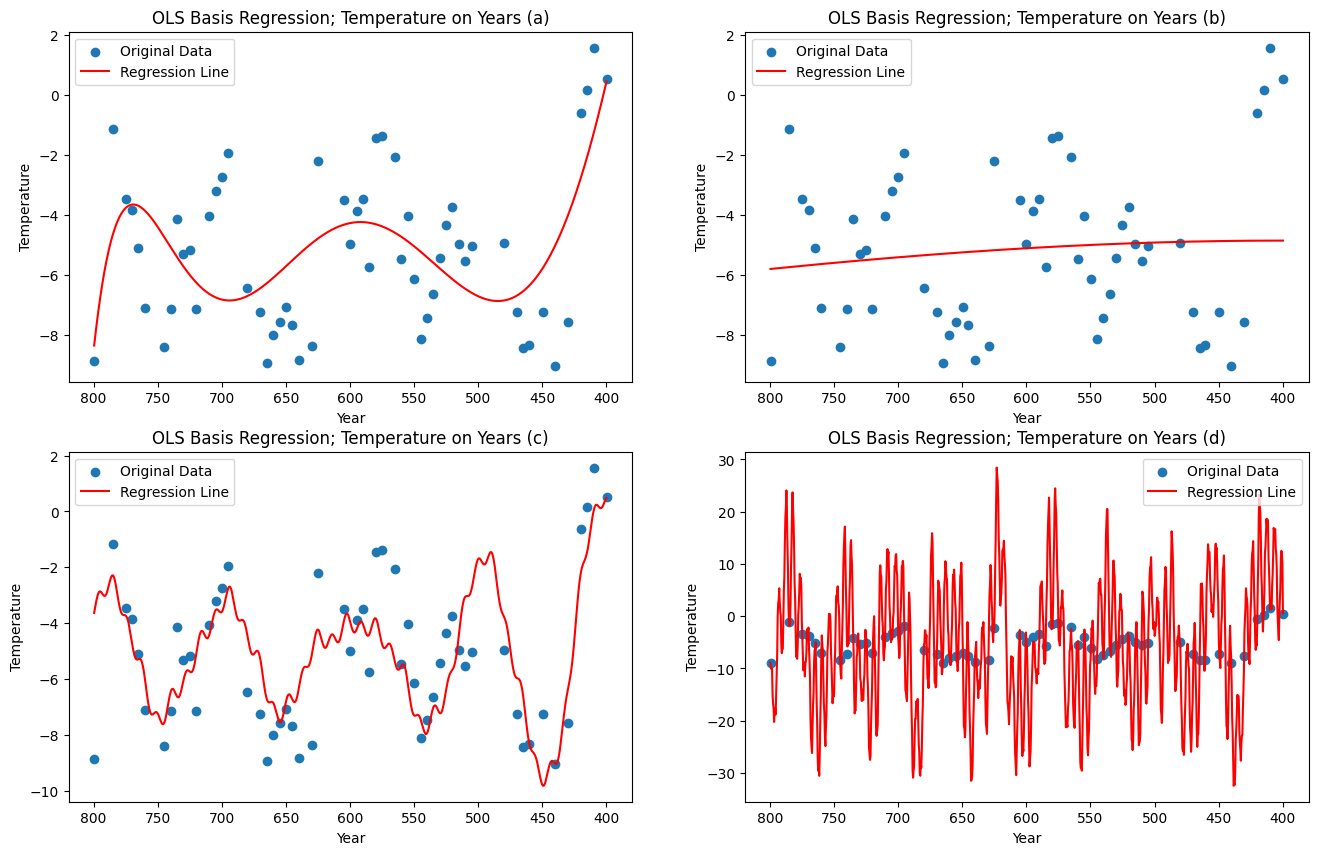

In [44]:
_, ax = plt.subplots(2,2, figsize = (16,10))

for i, part in enumerate(['a', 'b', 'c' ,'d']):
  # Plotting the original data
  phi_years_train = make_basis(year_train, part)
  w = find_weights(phi_years_train, temp_train)

  ax[i//2, i%2].scatter(year_train, temp_train, label = "Original Data")
  
  xs = np.linspace(year_train.min(), year_train.max(), 1000)
  ax[i//2, i%2].set_xlabel("Year")
  ax[i//2, i%2].set_ylabel("Temperature")
  ax[i//2, i%2].set_title(f"OLS Basis Regression; Temperature on Years ({part})")

  # TODO: Plot the regression line generated by your model. 
  ys = make_basis(xs, part) @ w
  ax[i//2, i%2].plot(xs, ys, color='red', label="Regression Line")
  ax[i//2, i%2].legend()
  
  ax[i//2, i%2].invert_xaxis()
  
plt.savefig("img_output/p3.1.png")

## Problem 3 Subpart 2

In [45]:
# Compute the MSE for each basis
parts = ['a', 'b', 'c', 'd']

for i, part in enumerate(parts):
    phi_train = make_basis(year_train, part)
    phi_test = make_basis(year_test, part)
    w = find_weights(phi_train, temp_train)

    predictions = phi_test @ w
    mse = model_mse(predictions, temp_test)
    print(f"MSE for part = {part}: {mse}")

MSE for part = a: 7.955749288900331
MSE for part = b: 9.099213739537463
MSE for part = c: 5.967024534016803
MSE for part = d: 58.89042789823659


# Problem 4

## Problem 4 Subpart 5

In [46]:
def find_lasso_weights(lam, X, y):
    """
    Fit the weights of a LASSO linear regression through the coordinate descent algorithm.

    :param lam: the lambda parameter
    :param X: the design matrix with training set features
    :param y: the training set labels
    :return: the fitted weights
    """
    N, D = X.shape
    w = np.zeros(D)

    for _ in range(500):
        w_old = w.copy()

        for j in range(D):
            r = y - X @ w + X[:, j] * w[j]
            rho = X[:, j].T @ r
            z = X[:, j].T @ X[:, j]

            if j == 0:
                w[j] = rho / z
            else:
                if rho < -lam:
                    w[j] = (rho + lam) / z
                elif rho > lam:
                    w[j] = (rho - lam) / z
                else:
                    w[j] = 0.0

        # Check if it converges
        if np.linalg.norm(w - w_old) < 1e-6:
            break
    return w



In [47]:
# Helper function for standardizing inputs to LASSO
def preprocess_lasso(X):
    X = make_basis(X, part='d')
    X[:, 1:] = (X[:, 1:] - X[:, 1:].mean(axis = 0)) / X[:, 1:].std(axis = 0)
    return X

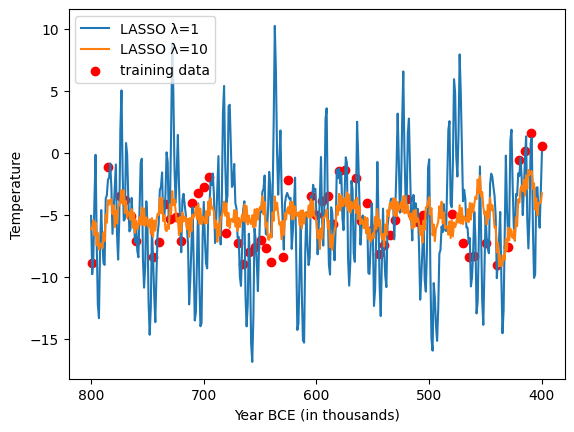

In [48]:
# Fit the weights for both models
phi_x_train = preprocess_lasso(year_train)
lam1, lam2 = 1, 10
w1 = find_lasso_weights(lam1, phi_x_train, temp_train)
w2 = find_lasso_weights(lam2, phi_x_train, temp_train)

# Plot functions
x_array = np.arange(400, 800 + 1, 1)
phi_x_array = preprocess_lasso(x_array)

# TODO: Plot the regression line generated by your model. 
y_pred1 = phi_x_array @ w1
y_pred2 = phi_x_array @ w2

plt.plot(x_array, y_pred1, label=f"LASSO λ={lam1}")
plt.plot(x_array, y_pred2, label=f"LASSO λ={lam2}")

plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.legend()
plt.xticks(np.arange(400, 800 + 100, 100))
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")

plt.gca().invert_xaxis()
# save figure to img_output directory
plt.savefig("img_output/p4.5.png", bbox_inches = "tight")
plt.show()

In [49]:
# Compute the MSE for both values of lambda
y_train_pred1 = phi_x_train @ w1
y_train_pred2 = phi_x_train @ w2

mse1 = np.mean((temp_train - y_train_pred1) ** 2)
mse2 = np.mean((temp_train - y_train_pred2) ** 2)

print(f"MSE (λ={lam1}): {mse1}")
print(f"MSE (λ={lam2}): {mse2}")

MSE (λ=1): 2.1606887216847848
MSE (λ=10): 4.028753252957758
